# Why the capped $d\sigma/dq$ grows a peak

> **Historical.** The current data release has **no impact-parameter cap**:
> `attrs['b_constrained_max_m']` is `NaN`, the $b$-integral runs out to
> infinity, and the only cutoff is the inner one at $R_\text{eff}$. The peak
> this notebook explains was a feature of the *capped* cross section used up to
> the v6 cube, and it is not in the released spectra any more. The notebook is
> kept because the projection argument is what makes that spectrum
> comprehensible — it is the answer to "why did the capped spectrum have a
> plateau and a horn?", and it is also the cleanest statement of why a hard
> cutoff on kick *magnitude* never becomes a hard cutoff on the *reading*, which
> is still true and still shapes the endpoint at $q_\text{max}$.
>
> The hardware scale that used to be $b_\text{cap}$ has not gone away; it moved.
> It is now the aperture of the post-hoc flux cut $m_\text{cut}$ (see
> `release/README.md` section 5.4), which closes the excluded region on the
> right without touching the cross section. Nothing below has been recomputed:
> the numbers and figures are the capped-scheme ones, on purpose.

**Paper element.** None. This was background on the impact-parameter cap that
the cross section and the transit count both applied up to v6.

**Private, pedagogical.** Nothing here feeds a limit and nothing here reads the
data release. It is the companion to the impact-parameter-cap explainer
(`scripts/figure_impact_parameter_cap.py`, figure
[`07_impact_parameter_cap`](png/07_impact_parameter_cap.png)) and uses exactly
the same example numbers, so the two agree — including in being about the
retired capped scheme.

Capping the impact parameter at $b_{\mathrm{cap}}$ throws flybys away, so the
differential cross section $d\sigma/dq$ can only go **down**. And yet the capped
curve is not a monotonically falling power law any more: it is flat at small
$q$, **rises** up to a sharp maximum at the crossover
$q_* = 2\alpha/(v\,b_{\mathrm{cap}})$, and only then falls like $q^{-3}$ again,
up to the sensor-radius endpoint $q_{\mathrm{max}}$. An interior maximum where the physics only ever removed things looks wrong.

It is not. The peak is a *projection* effect, and by the end of this notebook it
should look inevitable. Three facts do all the work:

1. A flyby at impact parameter $b$ delivers a kick of a **fixed magnitude**
   $q_\perp(b) = 2\alpha/(b\,v)$, pointed **sideways** in a random direction.
2. The sensor measures **one component**, $q_z = q_\perp\cos\phi$, with the
   azimuth $\phi$ uniformly distributed.
3. Flybys are drawn from the area weight, $d\sigma = 2\pi b\,db$.

Fact 2 is the one that matters. A large kick pointed nearly sideways is *read
out* as a small number, so a hard cutoff on kick **magnitude** does not become a
hard cutoff on the **reading**. What survives at the cutoff is the pile-up of
readings from kicks caught near their turning point &mdash; a "horn". That horn is
the peak.

The plan:

| section | question |
|---|---|
| 1 | What does **one** flyby look like at the read-out? |
| 2 | What do **many** flybys look like with no cap? |
| 3 | What changes when the cap removes every small kick? |
| 4 | Where else does nature do this? (rotating galaxies, NMR) |
| 5 | Numerical self-consistency checks |

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.gridspec import GridSpec

from luhdm import config, units
from luhdm import cross_section as xs

# --- example numbers: v and b_cap match scripts/figure_impact_parameter_cap.py;
# alpha_n differs (1.75e-6 here vs 4.13e-6 there -- both arbitrary, picked only
# to land the crossover q* somewhere convenient to plot). That difference is
# immaterial: every claim demonstrated below (arcsine shape, q* location,
# peak/plateau = 3*pi/4, toy-vs-production and Monte-Carlo agreement) is a
# statement about the *shape* of dsigma/dq, not about the coupling's value. --
ALPHA_N = 1.75e-6                     # coupling per neutron
ALPHA = ALPHA_N * config.N_NEUTRONS   # N_NEUTRONS = m_magnet/(2u), includes the /2
V = 1e-3                              # incoming speed [c]
B_CAP = 0.1                           # b_constrained_max = 10 cm (production cap)
CONV = units.conv_m2pGeV(1.0)         # 1 m expressed in GeV^-1

# crossover: the kick magnitude delivered by a flyby that just grazes the cap
QSTAR = 2 * ALPHA / (V * B_CAP * CONV)

SEED = 20260729
rng_flyby = np.random.default_rng(SEED)
rng_mc = np.random.default_rng(SEED + 1)
rng_gas = np.random.default_rng(SEED + 2)


def q_perp(b_m):
    """Kick magnitude [GeV] delivered by a massless-mediator flyby at b [m]."""
    return 2 * ALPHA / (np.asarray(b_m, float) * V) / CONV


def b_max_m(q):
    """Inverse of q_perp: the impact parameter whose kick magnitude is q."""
    return 2 * ALPHA / (np.asarray(q, float) * V) / CONV


def arcsine(qz, qp):
    """Density of one component of a fixed-length 2-D vector of length qp."""
    qz = np.asarray(qz, float)
    rad = qp * qp - qz * qz
    return np.where(rad > 0,
                    1.0 / (np.pi * np.sqrt(np.where(rad > 0, rad, 1.0))), 0.0)


def dsigma_toy(q, b_lo, b_hi, n=3000):
    """Toy dsigma/dq: sum the per-flyby arcsine densities over b in [b_lo, b_hi],
    weighted by the area element 2 pi b db (everything in natural units).

    The b-samples are placed as b = b_max(q) cos(theta) with theta on a uniform
    mid-point grid. That crowds them towards b_max(q), which is exactly where
    the arcsine horn of that shell sits, and the integrable 1/sqrt of the horn
    cancels against db -- so a plain mid-point rule is accurate everywhere.
    """
    q = np.atleast_1d(np.asarray(q, float))
    bM = b_max_m(q)
    hi = np.minimum(b_hi, bM)
    lo = np.minimum(b_lo, hi)
    th_lo = np.arccos(np.clip(hi / bM, 0.0, 1.0))
    th_hi = np.arccos(np.clip(lo / bM, 0.0, 1.0))
    mid = (np.arange(n) + 0.5) / n
    t = th_lo[:, None] + (th_hi - th_lo)[:, None] * mid[None, :]
    b = bM[:, None] * np.cos(t)
    db = bM[:, None] * np.sin(t) * ((th_hi - th_lo)[:, None] / n)
    return np.sum(2 * np.pi * CONV**2 * b * arcsine(q[:, None], q_perp(b)) * db,
                  axis=1)


def shell(q, b, dlnb):
    """What one thin shell of impact parameters [b, b e^dlnb] contributes."""
    return 2 * np.pi * CONV**2 * b**2 * arcsine(q, q_perp(b)) * dlnb


# --- house style: viridis for physical curves, #d62728 for cap-related -------
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "mathtext.fontset": "dejavusans", "axes.axisbelow": True,
})
C_DARK = plt.cm.viridis(0.10)
C_LIGHT = plt.cm.viridis(0.74)
C_RED = "#d62728"        # reserved for anything the cap touches
C_GUIDE = "#555555"
C_CRUDE = "#444444"


def halo(t, lw=3.0):
    """Path-effect halo instead of an opaque bbox, so curves stay visible."""
    t.set_path_effects([pe.Stroke(linewidth=lw, foreground="w"), pe.Normal()])
    return t


for _d in ("png", "svg", "pdf"):
    Path(_d).mkdir(exist_ok=True)


def save_figure(fig, name, **kw):
    # png/, svg/ and pdf/, notebook-number prefix. No release stamp: this
    # notebook derives everything from closed-form physics, not from a cube.
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"alpha   = {ALPHA:.4e}   (alpha_n = {ALPHA_N:.3g}, N_n = {config.N_NEUTRONS:.4e})")
print(f"v       = {V:g} c")
print(f"b_cap   = {B_CAP:g} m")
print(f"q*      = {QSTAR:.2f} GeV      (= 2 alpha / (v b_cap), the kick from a grazing flyby)")
print(f"b_max(q*) = {b_max_m(QSTAR):.4f} m   (sanity: equals b_cap)")

alpha   = 1.8653e+14   (alpha_n = 1.75e-06, N_n = 1.0659e+20)
v       = 0.001 c
b_cap   = 0.1 m
q*      = 736.11 GeV      (= 2 alpha / (v b_cap), the kick from a grazing flyby)
b_max(q*) = 0.1000 m   (sanity: equals b_cap)


## 1. One flyby: a fixed kick seen through a single component

Take a single flyby at some impact parameter $b$. It delivers a kick of
**magnitude** $q_\perp(b) = 2\alpha/(b v)$, and that magnitude is completely
fixed &mdash; there is nothing random about it. What *is* random is the direction:
the kick points sideways, in the plane transverse to the track, at an azimuth
$\phi$ that is uniform on $[0,2\pi)$. The sensor reads out one axis, so it
records

$$q_z = q_\perp\cos\phi .$$

The density of $q_z$ follows from "time spent per unit $q_z$":

$$p(q_z)\;\propto\;\Big|\frac{dq_z}{d\phi}\Big|^{-1}
 = \frac{1}{q_\perp|\sin\phi|} = \frac{1}{\sqrt{q_\perp^2-q_z^2}},
\qquad\text{normalised: }\;
p(q_z)=\frac{1}{\pi\sqrt{q_\perp^2-q_z^2}} .$$

This is the **arcsine law**, and it is U-shaped: it is *lowest* in the middle
and diverges (integrably) at $q_z=\pm q_\perp$. The picture to keep is a point
going round and round a circle at constant speed while you watch only its
shadow on a wall. The shadow races through the middle and comes to a dead stop
at each end before turning around, so it spends most of its time near the two
extremes. Those pile-ups at the turning points are the **horns**.

The panel below draws that: sampled azimuths for one flyby that just grazes the
cap (so its kick magnitude is exactly $q_\perp = q_*$), against the closed-form
arcsine density.

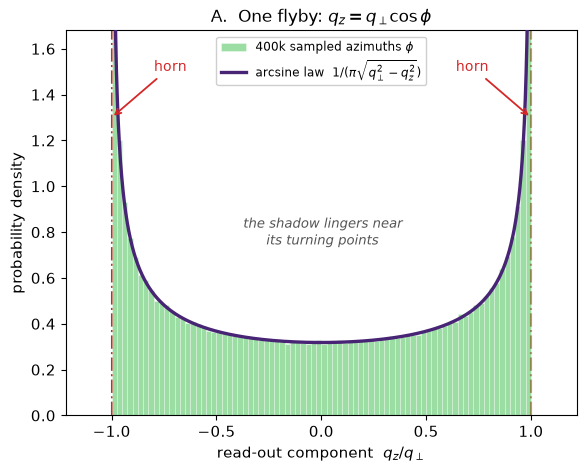

fraction of readings with |q_z| > 0.9 q_perp: 0.287 (analytic 0.287) -- a flat direction distribution is NOT a flat reading distribution


In [2]:
# One flyby that just grazes the cap: b = b_cap, so its kick magnitude is q*.
N_FLYBY = 400_000
qz_flyby = QSTAR * np.cos(rng_flyby.uniform(0, 2 * np.pi, N_FLYBY))
qz_grid = np.linspace(-0.99995, 0.99995, 4000)   # in units of q_perp


def panel_one_flyby(ax):
    ax.hist(qz_flyby / QSTAR, bins=np.linspace(-1, 1, 81), density=True,
            color=C_LIGHT, alpha=0.6, edgecolor="white", lw=0.4, zorder=2,
            label=f"{N_FLYBY // 1000}k sampled azimuths $\\phi$")
    ax.plot(qz_grid, arcsine(qz_grid, 1.0), color=C_DARK, lw=2.4, zorder=3,
            label=r"arcsine law  $1/(\pi\sqrt{q_\perp^2-q_z^2})$")
    for s in (-1, 1):
        ax.axvline(s, color=C_RED, ls="-.", lw=1.5, zorder=1)
        ax.annotate("horn", xy=(s, 1.30), xytext=(s * 0.72, 1.52),
                    color=C_RED, fontsize=10, ha="center", va="center",
                    arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.3))
    halo(ax.text(0.0, 0.80, "the shadow lingers near\nits turning points",
                 ha="center", va="center", fontsize=9.5, color=C_GUIDE,
                 style="italic"), 3.2)
    ax.set_ylim(0, 1.68)
    ax.set_xlim(-1.22, 1.22)
    ax.set_xlabel(r"read-out component  $q_z/q_\perp$")
    ax.set_ylabel("probability density")
    ax.set_title(r"A.  One flyby: $q_z=q_\perp\cos\phi$")
    ax.legend(loc="upper center", fontsize=8.8, framealpha=0.94)


fig, ax = plt.subplots(figsize=(6.6, 5.0))
panel_one_flyby(ax)
plt.show()

# how much of the time is spent in the outer 10% of the range?
frac = np.mean(np.abs(qz_flyby) > 0.9 * QSTAR)
print(f"fraction of readings with |q_z| > 0.9 q_perp: {frac:.3f} "
      f"(analytic {1 - 2 * np.arcsin(0.9) / np.pi:.3f}) "
      "-- a flat direction distribution is NOT a flat reading distribution")

## 2. Many flybys, no cap: every $q$ is somebody's horn

Now let the impact parameter vary. Flybys arrive spread uniformly over the
transverse plane, so a shell of impact parameters between $b$ and $b+db$ carries
the area weight $2\pi b\,db$. Each shell delivers its own fixed kick magnitude
$q_\perp(b) = 2\alpha/(bv)$ and therefore contributes its own arcsine, with its
own pair of horns sitting at $\pm q_\perp(b)$. Adding them up over
$b\in(0,\infty)$,

$$\frac{d\sigma}{dq} \;=\; \int_0^\infty 2\pi b\,db\;
\frac{1}{\pi\sqrt{q_\perp(b)^2 - q^2}} \;=\; \frac{2\pi\alpha^2}{v^2 q^3},$$

which is precisely `cross_section_rutherford_projection` &mdash; but only in the
idealized $R_\text{eff}\to0$ limit. The coded (production) function instead
starts the $b$-integral at the sensor radius $R_\text{eff}$, so no shell has a
kick magnitude above $q_{\mathrm{max}} = 2\alpha/(v\,R_\text{eff})$: the shell
sum is exactly zero beyond that endpoint rather than continuing as $q^{-3}$
forever.

The figure makes the mechanism visible. Each thin curve is one shell: flat at
small $q$ (you are on the shallow part of that shell's arcsine), then a horn
where the shell's own kick magnitude sits, then nothing beyond it (that shell
simply cannot read out more than it delivers). Because $b$ is continuous, the
horns are packed infinitely densely along the $q$ axis: **every $q$ below
$q_{\mathrm{max}}$ is some shell's horn** &mdash; there is a very last one,
contributed by the $b=R_\text{eff}$ shell, sitting exactly at $q_{\mathrm{max}}$
&mdash; and no $q$ in that range is special. The dotted line shows what happens
with only 21 shells &mdash; you can still see the individual horns as ripples.
Fill in the continuum and the ripples wash out into a perfectly featureless
power law below $q_{\mathrm{max}}$.

Keep that in mind: the smooth $q^{-3}$ is not "smooth because nothing is
happening". It is smooth because a horn is happening *everywhere* below
$q_{\mathrm{max}}$.

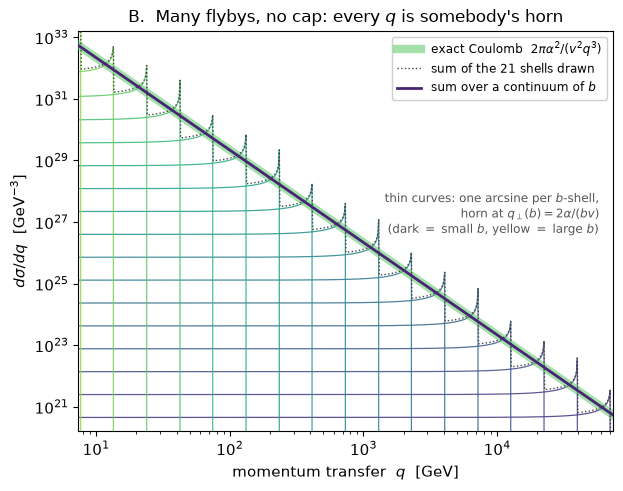

toy sum vs closed form, max relative deviation: 5.10e-09


In [3]:
q_grid = np.geomspace(QSTAR / 100, QSTAR * 100, 900)

# The toy has to integrate over the SAME domain as the production function: the
# b-integral starts at the sensor radius R_eff (no flyby passes closer, so the
# impulse saturates at q_max = 2 alpha / (v conv(R_eff))) and its outer edge is
# pushed far outside the window. Starting the toy below R_eff would add shells
# the production code no longer has, and the two would part company as q climbs
# towards q_max.
B_LO_INT, B_HI_INT = config.R_EFF, B_CAP * 1e8
toy_uncapped = dsigma_toy(q_grid, B_LO_INT, B_HI_INT)
exact_uncapped = xs.cross_section_rutherford_projection(q_grid, ALPHA, V)

# the handful of shells actually drawn, and their (coarse) sum
N_FAN = 21
FAN_COLORS = plt.cm.viridis(np.linspace(0.05, 0.92, N_FAN))
b_fan_uncapped = np.geomspace(B_CAP / 300, B_CAP * 300, N_FAN)
DLNB_UNCAPPED = np.log(b_fan_uncapped[1] / b_fan_uncapped[0])
crude_uncapped = sum(shell(q_grid, b, DLNB_UNCAPPED) for b in b_fan_uncapped)


def panel_uncapped(ax):
    for b, col in zip(b_fan_uncapped, FAN_COLORS):
        ax.plot(q_grid, shell(q_grid, b, DLNB_UNCAPPED), color=col, lw=0.9,
                alpha=0.85, zorder=2)
    ax.plot(q_grid, exact_uncapped, color=C_LIGHT, lw=6.0, alpha=0.55, zorder=3,
            label=r"exact Coulomb  $2\pi\alpha^2/(v^2q^3)$")
    ax.plot(q_grid, crude_uncapped, color=C_CRUDE, lw=1.0, ls=":", zorder=4,
            label=f"sum of the {N_FAN} shells drawn")
    ax.plot(q_grid, toy_uncapped, color=C_DARK, lw=2.0, zorder=5,
            label="sum over a continuum of $b$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(q_grid[0], q_grid[-1])
    ax.set_ylim(toy_uncapped.min() * 0.3, toy_uncapped.max() * 3)
    ax.set_xlabel("momentum transfer  $q$  [GeV]")
    ax.set_ylabel(r"$d\sigma/dq$  [GeV$^{-3}$]")
    ax.set_title("B.  Many flybys, no cap: every $q$ is somebody's horn")
    ax.legend(loc="upper right", fontsize=8.8, framealpha=0.94)
    halo(ax.text(0.975, 0.60, "thin curves: one arcsine per $b$-shell,\n"
                 r"horn at $q_\perp(b)=2\alpha/(bv)$" "\n"
                 r"(dark $=$ small $b$, yellow $=$ large $b$)",
                 transform=ax.transAxes, fontsize=8.6, color=C_GUIDE,
                 va="top", ha="right"), 3.2)


fig, ax = plt.subplots(figsize=(6.9, 5.2))
panel_uncapped(ax)
plt.show()

print("toy sum vs closed form, max relative deviation: "
      f"{np.max(np.abs(toy_uncapped / exact_uncapped - 1)):.2e}")

## 3. Cap the impact parameter: one horn is left standing

The production cap says: ignore any flyby with $b > b_{\mathrm{cap}}$. Because
$q_\perp(b)$ falls as $1/b$, that is the same statement as

$$q_\perp \;\ge\; q_* \;=\; \frac{2\alpha}{v\,b_{\mathrm{cap}}},$$

i.e. **there is now a smallest kick magnitude anyone can deliver** &mdash; on top
of the largest one, $q_{\mathrm{max}} = 2\alpha/(v\,R_\text{eff})$, that was
already there from the sensor radius (section 2). The domain of $b$ is really
an annulus $R_\text{eff}\le b\le b_{\mathrm{cap}}$ with two edges, not the
half-line; this section only adds the outer one. In the fan picture we simply
delete every shell whose horn sits below $q_*$ and keep the rest untouched.

Two consequences, and they pull in opposite directions:

* **Below $q_*$** there are no horns left at all. Readings below $q_*$ still
  happen &mdash; a big kick pointed nearly sideways reads small &mdash; but they come only
  from the *shallow flanks* of the surviving arcsines. Flanks are flat, and
  what you get is a **plateau**: $d\sigma/dq \to 8\alpha^2/(3v^2q_*^3)$,
  independent of $q$.
* **Above $q_*$** nothing has been removed: those readings were always
  dominated by small-$b$ flybys, which the cap never touched. The curve is
  *identical* to the uncapped $q^{-3}$, not approximately but exactly, for
  every $q_* < q < q_{\mathrm{max}}$ &mdash; above $q_{\mathrm{max}}$ both curves
  are already zero, cut off by the sensor radius rather than by the cap.

The peak sits at the seam. At $q_*$ the last surviving horn is still there in
full, so the capped curve reaches the full uncapped value $2\pi\alpha^2/(v^2q_*^3)$
there. Just below $q_*$ you start losing shells, and you lose them fast: the
lost fraction grows like $\sqrt{q_*-q}$, which easily beats the gentle $q^{-3}$
rise. So the curve turns over **exactly at $q_*$**, with a square-root cusp on
its left flank &mdash; the same square root as the horn itself. The peak *is* the
last horn.

That also fixes the height of the step. Peak over plateau is

$$\frac{2\pi\alpha^2/(v^2q_*^3)}{8\alpha^2/(3v^2q_*^3)} = \frac{3\pi}{4}\approx 2.36,$$

a pure number: no coupling, no speed, no cap in it (strictly, both this ratio
and the plateau formula above pick up an $O\!\big((q_*/q_{\mathrm{max}})^3\big)$
correction from the finite outer edge of the shell sum at $R_\text{eff}$; here
$b_{\mathrm{cap}}\gg R_\text{eff}$, so $q_*/q_{\mathrm{max}} = R_\text{eff}/b_{\mathrm{cap}}$
is tiny and the correction is of order $10^{-8}$ &mdash; negligible, but it is why
these are not exact identities for every geometry).

Three independent curves are drawn on top of each other below: the toy sum of
arcsines built here, the production function
`cross_section_rutherford_projection_capped`, and a brute-force Monte Carlo that
never uses any of the algebra (throw $b$ from the area weight up to
$b_{\mathrm{cap}}$, throw $\phi$ uniformly, histogram $|q_z|$). If the story is
right they lie on top of each other, and they do.

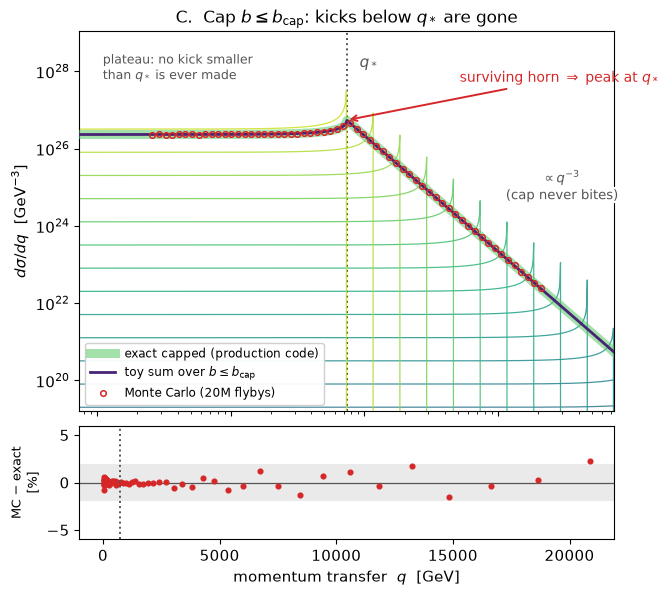

peak (at q*)          = 5.48065e+26 GeV^-3
plateau (q -> 0)      = 2.32606e+26 GeV^-3
peak / plateau        = 2.356194   (3*pi/4 = 2.356194)
toy vs exact, max rel = 2.76e-08
MC  vs exact, max rel = 2.28% over 60 bins with >= 2000 entries (rms 0.58%, max pull 2.51 sigma)


In [4]:
toy_capped = dsigma_toy(q_grid, B_LO_INT, B_CAP)
exact_capped = xs.cross_section_rutherford_projection_capped(q_grid, ALPHA, V, B_CAP)

b_fan_capped = np.geomspace(B_CAP / 1e4, B_CAP, N_FAN)
DLNB_CAPPED = np.log(b_fan_capped[1] / b_fan_capped[0])

# ---------------------------------------------------------------------------
# Brute-force Monte Carlo: no arcsine, no retained fraction, just flybys.
#   b ~ area weight on [0, b_cap]  ->  b = b_cap sqrt(U)
#   phi ~ uniform,  q_z = q_perp(b) cos(phi)
# The ensemble carries a total cross section sigma_tot = pi b_cap^2, so a
# density-normalised histogram of |q_z| times sigma_tot is dsigma/d|q_z|;
# dsigma/dq in the production (signed-component) convention is half of that.
# ---------------------------------------------------------------------------
N_MC, MC_CHUNK = 20_000_000, 2_000_000
mc_edges = np.geomspace(QSTAR / 30, QSTAR * 30, 61)
mc_counts = np.zeros(len(mc_edges) - 1)
for _ in range(N_MC // MC_CHUNK):
    b_mc = B_CAP * np.sqrt(rng_mc.random(MC_CHUNK))
    qz_mc = q_perp(b_mc) * np.cos(rng_mc.uniform(0, 2 * np.pi, MC_CHUNK))
    mc_counts += np.histogram(np.abs(qz_mc), bins=mc_edges)[0]

SIGMA_TOT = np.pi * (B_CAP * CONV) ** 2                     # GeV^-2
mc_dsigma = 0.5 * mc_counts / N_MC / np.diff(mc_edges) * SIGMA_TOT
mc_centres = np.sqrt(mc_edges[:-1] * mc_edges[1:])

# compare like with like: average the exact curve across each bin
_sub = np.linspace(0, 1, 129)
mc_exact = np.array([
    np.trapezoid(
        xs.cross_section_rutherford_projection_capped(
            mc_edges[i] + (mc_edges[i + 1] - mc_edges[i]) * _sub, ALPHA, V, B_CAP),
        mc_edges[i] + (mc_edges[i + 1] - mc_edges[i]) * _sub)
    / (mc_edges[i + 1] - mc_edges[i])
    for i in range(len(mc_centres))])
mc_rel = mc_dsigma / mc_exact - 1
mc_pull = mc_rel * np.sqrt(np.maximum(mc_counts, 1))
MC_MIN_COUNTS = 2000
mc_good = mc_counts >= MC_MIN_COUNTS

# the true peak height: at q* the cap has not removed anything yet
Y_PEAK = float(xs.cross_section_rutherford_projection(np.array([QSTAR]), ALPHA, V)[0])


def panel_capped(ax, ax_resid=None):
    for b, col in zip(b_fan_capped, FAN_COLORS):
        ax.plot(q_grid, shell(q_grid, b, DLNB_CAPPED), color=col, lw=0.9,
                alpha=0.85, zorder=2)
    ax.plot(q_grid, exact_capped, color=C_LIGHT, lw=6.5, alpha=0.55, zorder=3,
            label="exact capped (production code)")
    ax.plot(q_grid, toy_capped, color=C_DARK, lw=2.0, zorder=5,
            label=r"toy sum over $b\leq b_{\mathrm{cap}}$")
    ax.plot(mc_centres, mc_dsigma, "o", ms=4.0, mfc="none", mec=C_RED, mew=1.1,
            zorder=7, label=f"Monte Carlo ({N_MC // 1_000_000}M flybys)")
    ax.axvline(QSTAR, color=C_GUIDE, ls=":", lw=1.4, zorder=1)
    ax.annotate(r"surviving horn $\Rightarrow$ peak at $q_*$",
                xy=(QSTAR, Y_PEAK), xytext=(QSTAR * 7, Y_PEAK * 12),
                color=C_RED, fontsize=10, ha="left", va="center",
                arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.4))
    halo(ax.text(q_grid[0] * 1.5, Y_PEAK * 9,
                 "plateau: no kick smaller\nthan $q_*$ is ever made",
                 fontsize=9, color=C_GUIDE, ha="left", va="bottom"), 3.2)
    halo(ax.text(QSTAR * 1.25, Y_PEAK * 30, "$q_*$", fontsize=11,
                 color=C_GUIDE, ha="left", va="center"), 3.0)
    halo(ax.text(QSTAR * 40, Y_PEAK * 2e-2, r"$\propto q^{-3}$" "\n(cap never bites)",
                 fontsize=9.5, color=C_GUIDE, ha="center", va="center"), 3.2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(q_grid[0], q_grid[-1])
    ax.set_ylim(Y_PEAK * 3e-8, Y_PEAK * 2e2)
    ax.set_ylabel(r"$d\sigma/dq$  [GeV$^{-3}$]")
    ax.set_title(r"C.  Cap $b\leq b_{\mathrm{cap}}$: kicks below $q_*$ are gone")
    ax.legend(loc="lower left", fontsize=8.8, framealpha=0.94)

    if ax_resid is None:
        ax.set_xlabel("momentum transfer  $q$  [GeV]")
        return
    plt.setp(ax.get_xticklabels(), visible=False)
    ax_resid.axhspan(-2, 2, color=C_GUIDE, alpha=0.12, lw=0)
    ax_resid.axhline(0, color=C_GUIDE, lw=0.9)
    ax_resid.plot(mc_centres, 100 * mc_rel, "o", ms=3.4, color=C_RED)
    ax_resid.axvline(QSTAR, color=C_GUIDE, ls=":", lw=1.4)
    ax_resid.set_ylim(-6, 6)
    ax_resid.set_xlabel("momentum transfer  $q$  [GeV]")
    ax_resid.set_ylabel("MC $-$ exact\n[%]", fontsize=9)


fig = plt.figure(figsize=(6.9, 6.6))
_gs = GridSpec(2, 1, height_ratios=[1.0, 0.30], hspace=0.06, figure=fig)
panel_capped(fig.add_subplot(_gs[0]), fig.add_subplot(_gs[1]))
plt.show()

plateau = float(xs.cross_section_rutherford_projection_capped(
    np.array([QSTAR / 1000]), ALPHA, V, B_CAP)[0])
print(f"peak (at q*)          = {Y_PEAK:.5e} GeV^-3")
print(f"plateau (q -> 0)      = {plateau:.5e} GeV^-3")
print(f"peak / plateau        = {Y_PEAK / plateau:.6f}   (3*pi/4 = {3 * np.pi / 4:.6f})")
print(f"toy vs exact, max rel = {np.max(np.abs(toy_capped / exact_capped - 1)):.2e}")
print(f"MC  vs exact, max rel = {np.max(np.abs(mc_rel[mc_good])) * 100:.2f}% "
      f"over {mc_good.sum()} bins with >= {MC_MIN_COUNTS} entries "
      f"(rms {np.sqrt(np.mean(mc_rel[mc_good]**2)) * 100:.2f}%, "
      f"max pull {np.max(np.abs(mc_pull[mc_good])):.2f} sigma)")

## 4. The same effect, one field over: the double-horned 21 cm line

Radio astronomers have been staring at this kernel for decades. Neutral hydrogen
in a rotating galaxy emits the 21 cm line; what a single-dish telescope records
is the distribution of the **line-of-sight component** of the gas velocity. Gas
in a circular orbit at speed $v(R)$ contributes

$$p(v_{\rm los}) \;=\; \frac{1}{\pi\sqrt{v(R)^2 - v_{\rm los}^2}},$$

the identical arcsine, for the identical reason: a fixed-magnitude velocity seen
through one projection axis. Everything from section 1 carries over with
$q_\perp \to v(R)$ and $b \to R$.

The mini-simulation below throws gas parcels (radii from the area weight,
azimuths uniform) and histograms the line-of-sight velocity:

* **(a) A ring** &mdash; all the gas at one circular speed &mdash; gives one clean arcsine:
  the textbook **double-horned profile**, with horns at $\pm v_c$.
* **(b) A disk whose rotation speed runs continuously down to zero** stacks
  arcsines with every horn position from $0$ to $v_c$. Exactly as in section 2,
  the horns wash each other out and the profile is smooth and single-peaked.
* **(c) Punch a hole in that disk**, so that no gas is slower than $v_{\min}$,
  and the horns snap back at $\pm v_{\min}$. Nothing was added; slow gas was
  removed, and the removal exposed the slowest surviving horn.

**The map to our problem:** the cap $b \le b_{\mathrm{cap}}$ is the hole. It
imposes a sharp *minimum kick magnitude* $q_*$ exactly as the hole imposes a
sharp minimum circular speed $v_{\min}$, and the peak at $q_*$ is the same
surviving horn as the one at $v_{\min}$. The sensor radius $b \ge R_\text{eff}$
is the disc's rim: our real $d\sigma/dq$ is really both punctured *and*
rim-truncated &mdash; a disc with a hole **and** a hard outer edge, i.e. a hard
maximum circular speed $v_{\max}$ (mapping to the endpoint $q_{\mathrm{max}}$ at
the small-$b$ end). The three panels above draw only the hole, since it is the
cap, not $R_\text{eff}$, that produces the peak this notebook is about.

(The same $1/\sqrt{\cdot}$ kernel is also why an NMR spectrum of a randomly
oriented powder shows the **Pake doublet**: a fixed dipolar splitting projected
onto the field direction over random orientations piles up at its turning
points.)

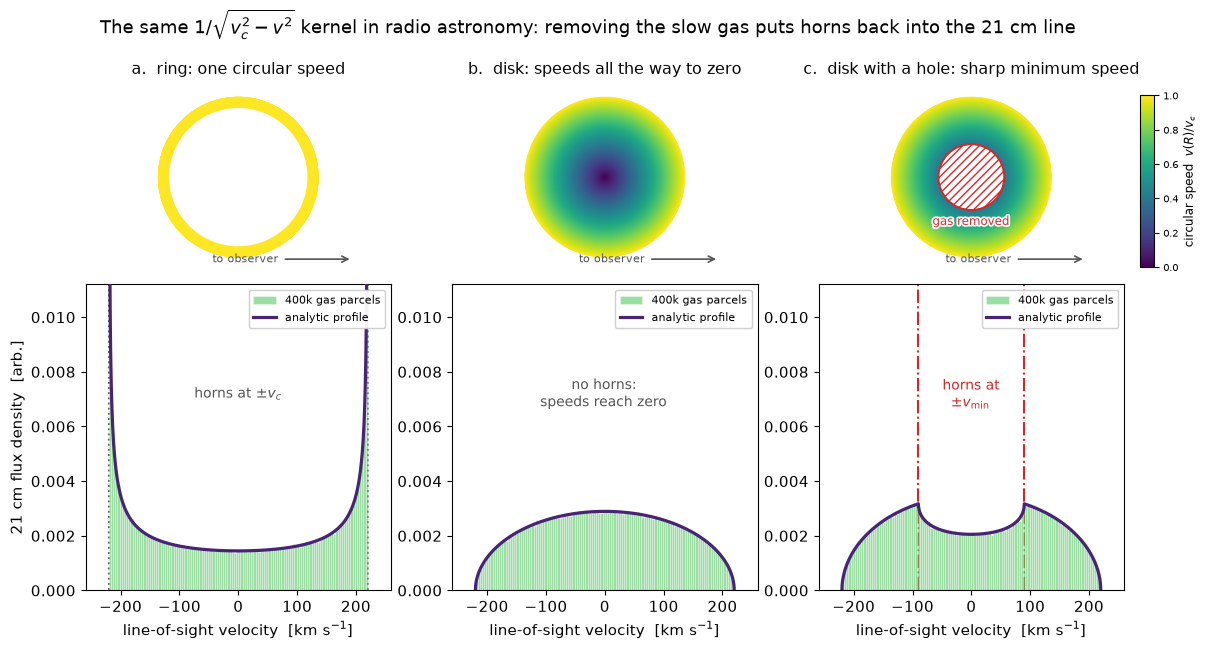

ring : simulation vs analytic profile, max deviation 5.27% (2.66 sigma -- these bins hold only a few thousand parcels each)
disk : simulation vs analytic profile, max deviation 4.57% (2.51 sigma -- these bins hold only a few thousand parcels each)
hole : simulation vs analytic profile, max deviation 4.58% (2.49 sigma -- these bins hold only a few thousand parcels each)


In [5]:
VC = 220.0        # km/s, outer circular speed
VMIN = 90.0       # km/s, the sharp minimum speed once a hole is punched
N_GAS = 400_000
v_grid = np.linspace(-VC * 0.99995, VC * 0.99995, 6000)


def profile_ring(v):
    return arcsine(v, VC)


def profile_disk(v):
    return 2.0 * np.sqrt(np.maximum(VC**2 - v**2, 0.0)) / (np.pi * VC**2)


def profile_hole(v):
    outer = np.sqrt(np.maximum(VC**2 - v**2, 0.0))
    inner = np.sqrt(np.maximum(VMIN**2 - v**2, 0.0))
    return 2.0 * (outer - inner) / (np.pi * (VC**2 - VMIN**2))


def sample_gas(kind, n=N_GAS):
    """Radii from the area weight (p(R) ~ R), azimuths uniform, v_los = v cos(phi).
    v(R) rises linearly with R, so p(v) ~ v on the allowed speed interval."""
    u = rng_gas.random(n)
    if kind == "ring":
        v = np.full(n, VC)
    elif kind == "disk":
        v = VC * np.sqrt(u)
    else:
        v = np.sqrt(VMIN**2 + (VC**2 - VMIN**2) * u)
    return v * np.cos(rng_gas.uniform(0, 2 * np.pi, n))


GAS_CASES = [
    ("ring", "a.  ring: one circular speed", profile_ring, 0.0),
    ("disk", "b.  disk: speeds all the way to zero", profile_disk, 0.0),
    ("hole", "c.  disk with a hole: sharp minimum speed", profile_hole, VMIN),
]

fig = plt.figure(figsize=(13.4, 6.6))
gs = GridSpec(2, 3, height_ratios=[0.62, 1.0], hspace=0.05, wspace=0.20,
              figure=fig)
gas_bins = np.linspace(-VC, VC, 121)
gas_checks = {}

for j, (kind, title, profile, v_horn) in enumerate(GAS_CASES):
    # --- face-on sketch, coloured by circular speed
    ax_sk = fig.add_subplot(gs[0, j])
    ax_sk.set_aspect("equal")
    ax_sk.set_xlim(-1.45, 1.45)
    ax_sk.set_ylim(-1.18, 1.18)
    ax_sk.axis("off")
    r_in = {"ring": 0.86, "disk": 0.0, "hole": VMIN / VC}[kind]
    for r in np.linspace(1.0, max(r_in, 1e-3), 220):
        ax_sk.add_patch(plt.Circle((0, 0), r, ec="none",
                                   fc=plt.cm.viridis(1.0 if kind == "ring" else r)))
    if r_in > 0:
        ax_sk.add_patch(plt.Circle((0, 0), r_in, fc="white", ec="none"))
    if kind == "hole":
        ax_sk.add_patch(plt.Circle((0, 0), r_in, fc="none", ec=C_RED,
                                   hatch="////", lw=1.4))
        halo(ax_sk.text(0, -0.55, "gas removed", color=C_RED, fontsize=8.5,
                        ha="center", va="center"), 2.6)
    ax_sk.annotate("", xy=(1.42, -1.02), xytext=(0.55, -1.02),
                   arrowprops=dict(arrowstyle="->", color=C_GUIDE, lw=1.2))
    ax_sk.text(0.5, -1.02, "to observer", color=C_GUIDE, fontsize=8,
               ha="right", va="center")
    ax_sk.set_title(title, fontsize=11.5)

    # --- line profile
    ax_p = fig.add_subplot(gs[1, j])
    v_los = sample_gas(kind)
    counts, _ = np.histogram(v_los, bins=gas_bins)
    ax_p.hist(v_los, bins=gas_bins, density=True, color=C_LIGHT, alpha=0.6,
              edgecolor="white", lw=0.4, zorder=2,
              label=f"{N_GAS // 1000}k gas parcels")
    ax_p.plot(v_grid, profile(v_grid), color=C_DARK, lw=2.3, zorder=3,
              label="analytic profile")
    if v_horn:
        for s in (-1, 1):
            ax_p.axvline(s * v_horn, color=C_RED, ls="-.", lw=1.5, zorder=1)
        halo(ax_p.text(0, 0.0072, "horns at\n" r"$\pm v_{\min}$", color=C_RED,
                       fontsize=10, ha="center", va="center", linespacing=1.4))
    elif kind == "ring":
        for s in (-1, 1):
            ax_p.axvline(s * VC, color=C_GUIDE, ls=":", lw=1.4, zorder=1)
        halo(ax_p.text(0, 0.0072, r"horns at $\pm v_c$", color=C_GUIDE,
                       fontsize=10, ha="center", va="center"))
    else:
        halo(ax_p.text(0, 0.0072, "no horns:\nspeeds reach zero", color=C_GUIDE,
                       fontsize=10, ha="center", va="center"))
    ax_p.set_xlim(-VC * 1.18, VC * 1.18)
    ax_p.set_ylim(0, 0.0112)
    ax_p.set_xlabel("line-of-sight velocity  [km s$^{-1}$]")
    if j == 0:
        ax_p.set_ylabel("21 cm flux density  [arb.]")
    ax_p.legend(loc="upper right", fontsize=8.2, framealpha=0.94)

    # bin-averaged analytic vs simulation, away from the divergent edges
    ctr = 0.5 * (gas_bins[:-1] + gas_bins[1:])
    fine = np.linspace(0, 1, 65)
    pred = np.array([
        np.trapezoid(profile(gas_bins[i] + np.diff(gas_bins)[i] * fine),
                     gas_bins[i] + np.diff(gas_bins)[i] * fine)
        for i in range(len(ctr))])
    sim = counts / N_GAS
    keep = (np.abs(ctr) < 0.9 * VC) & (counts > 500)
    rel = sim[keep] / pred[keep] - 1
    gas_checks[kind] = (float(np.max(np.abs(rel))),
                        float(np.max(np.abs(rel * np.sqrt(counts[keep])))))

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
cax = fig.add_axes([0.912, 0.60, 0.010, 0.26])
cb = fig.colorbar(sm, cax=cax)
cb.set_label("circular speed  $v(R)/v_c$", fontsize=8.5)
cb.ax.tick_params(labelsize=7.5)

fig.suptitle("The same $1/\\sqrt{v_c^2-v^2}$ kernel in radio astronomy: "
             "removing the slow gas puts horns back into the 21 cm line",
             fontsize=13, y=0.99)
fig.subplots_adjust(right=0.90)
save_figure(fig, "09_projection_peak_galaxy", bbox_inches="tight")
plt.show()

for kind, (dev, pull) in gas_checks.items():
    print(f"{kind:5s}: simulation vs analytic profile, max deviation {dev * 100:.2f}% "
          f"({pull:.2f} sigma -- these bins hold only a few thousand parcels each)")

## 5. Self-consistency: the peak is at $q_*$, for every cap

The claim is sharp enough to test numerically without any fitting: slide
$b_{\mathrm{cap}}$ over two decades, locate the maximum of
`cross_section_rutherford_projection_capped` on a fixed grid, and compare with
$q_*(b_{\mathrm{cap}}) = 2\alpha/(v\,b_{\mathrm{cap}})$. Since the capped curve
rises below $q_*$ and falls above it, the grid maximum has to land on one of the
two grid points bracketing $q_*$ &mdash; so "within one grid step" is the right
tolerance, and it is a genuine test of *where* the turnover is.

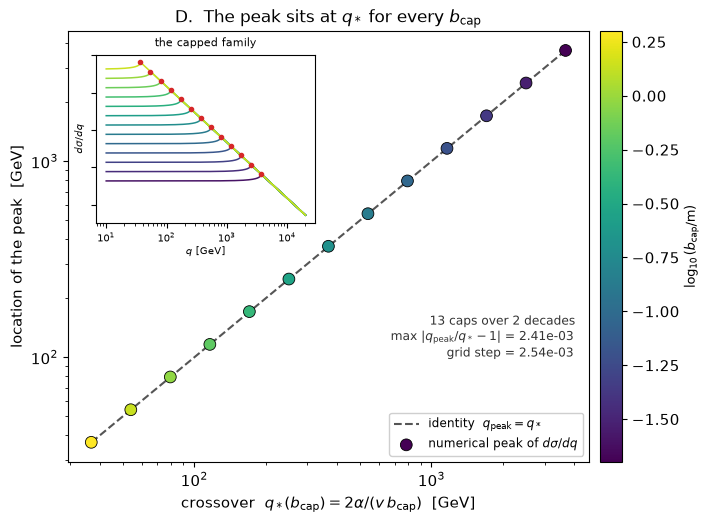

 b_cap [m]    q* [GeV]  q_peak [GeV]     peak/q*   in steps
    0.0200    3680.557      3681.295    1.000201     +0.079
    0.0294    2507.534      2511.012    1.001387     +0.547
    0.0431    1708.363      1708.428    1.000038     +0.015
    0.0632    1163.894      1165.319    1.001224     +0.483
    0.0928     792.952       794.864    1.002412     +0.951
    0.1363     540.232       540.805    1.001061     +0.419
    0.2000     368.056       368.883    1.002248     +0.886
    0.2936     250.753       250.979    1.000898     +0.354
    0.4309     170.836       171.193    1.002085     +0.822
    0.6325     116.389       116.475    1.000735     +0.290
    0.9283      79.295        79.448    1.001922     +0.758
    1.3626      54.023        54.054    1.000572     +0.226
    2.0000      36.806        36.870    1.001759     +0.694


In [6]:
b_caps = np.geomspace(0.02, 2.0, 13)
q_scan = np.geomspace(10.0, 2.0e4, 3001)      # one fixed grid for every cap
Q_STEP = q_scan[1] / q_scan[0]

q_stars = 2 * ALPHA / (V * b_caps * CONV)
capped_family = [xs.cross_section_rutherford_projection_capped(q_scan, ALPHA, V, bc)
                 for bc in b_caps]
q_peaks = np.array([q_scan[int(np.argmax(c))] for c in capped_family])


def panel_scan(ax, fig=None, inset=True):
    ax.plot(q_stars, q_stars, color=C_GUIDE, ls="--", lw=1.5, zorder=2,
            label=r"identity  $q_{\mathrm{peak}}=q_*$")
    sc = ax.scatter(q_stars, q_peaks, c=np.log10(b_caps), cmap="viridis", s=72,
                    zorder=4, edgecolor="k", lw=0.6,
                    label=r"numerical peak of $d\sigma/dq$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"crossover  $q_*(b_{\mathrm{cap}})=2\alpha/(v\,b_{\mathrm{cap}})$  [GeV]")
    ax.set_ylabel("location of the peak  [GeV]")
    ax.set_title(r"D.  The peak sits at $q_*$ for every $b_{\mathrm{cap}}$")
    ax.legend(loc="lower right", fontsize=8.8, framealpha=0.94)
    halo(ax.text(0.97, 0.235,
                 f"{len(b_caps)} caps over 2 decades\n"
                 f"max $|q_{{\\rm peak}}/q_*-1|$ = {np.max(np.abs(q_peaks / q_stars - 1)):.2e}\n"
                 f"grid step = {Q_STEP - 1:.2e}",
                 transform=ax.transAxes, fontsize=8.8, ha="right", va="bottom",
                 color="#333333"), 3.0)
    if fig is not None:
        cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.045)
        cb.set_label(r"$\log_{10}(b_{\mathrm{cap}}/\mathrm{m})$", fontsize=9)
    if not inset:
        return
    ax_in = ax.inset_axes([0.055, 0.555, 0.42, 0.39])
    for c, col in zip(capped_family,
                      plt.cm.viridis(np.linspace(0.05, 0.92, len(b_caps)))):
        ax_in.plot(q_scan, c, color=col, lw=1.1)
    ax_in.plot(q_peaks, [c.max() for c in capped_family], "o", ms=3.0,
               color=C_RED, zorder=5)
    ax_in.set_xscale("log")
    ax_in.set_yscale("log")
    ax_in.tick_params(labelsize=7)
    ax_in.set_yticklabels([])
    ax_in.set_xlabel("$q$ [GeV]", fontsize=7.5, labelpad=1)
    ax_in.set_ylabel(r"$d\sigma/dq$", fontsize=7.5, labelpad=1)
    ax_in.set_title("the capped family", fontsize=8)


fig, ax = plt.subplots(figsize=(7.2, 5.6))
panel_scan(ax, fig)
plt.show()

print(f"{'b_cap [m]':>10}  {'q* [GeV]':>10}  {'q_peak [GeV]':>12}  "
      f"{'peak/q*':>10}  {'in steps':>9}")
for bc, qs, qp in zip(b_caps, q_stars, q_peaks):
    print(f"{bc:10.4f}  {qs:10.3f}  {qp:12.3f}  {qp / qs:10.6f}  "
          f"{np.log(qp / qs) / np.log(Q_STEP):+9.3f}")

### The assembled explainer

All four panels together. Saved to `png/`, `svg/` and `pdf/` as
`09_projection_peak`.

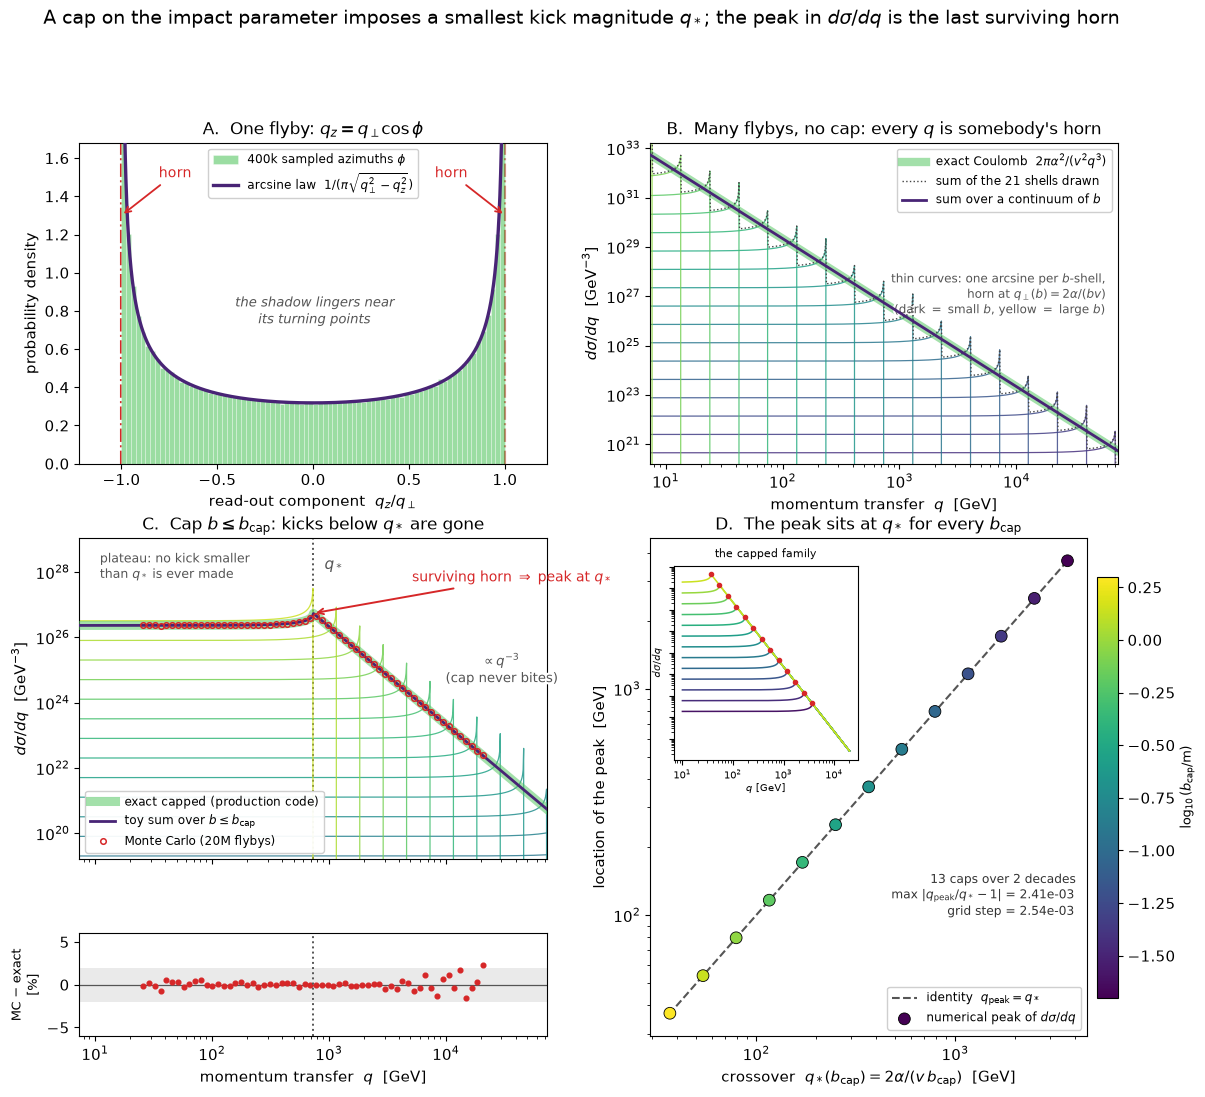

In [7]:
fig = plt.figure(figsize=(13.4, 11.6))
gs = GridSpec(3, 2, height_ratios=[1.0, 1.0, 0.32], hspace=0.30, wspace=0.22,
              figure=fig)
panel_one_flyby(fig.add_subplot(gs[0, 0]))
panel_uncapped(fig.add_subplot(gs[0, 1]))
ax_c = fig.add_subplot(gs[1, 0])
panel_capped(ax_c, fig.add_subplot(gs[2, 0], sharex=ax_c))
panel_scan(fig.add_subplot(gs[1:, 1]), fig)
fig.suptitle("A cap on the impact parameter imposes a smallest kick magnitude "
             "$q_*$; the peak in $d\\sigma/dq$ is the last surviving horn",
             fontsize=13.5, y=0.995)
save_figure(fig, "09_projection_peak", bbox_inches="tight")
plt.show()

### Checks

Everything asserted below is a statement the notebook made in words.

In [8]:
# 1. Above q* the cap changes nothing at all -- bit-for-bit, not approximately.
q_fine = np.geomspace(QSTAR / 50, QSTAR * 50, 20001)
above = q_fine > QSTAR
assert np.array_equal(
    xs.cross_section_rutherford_projection_capped(q_fine, ALPHA, V, B_CAP)[above],
    xs.cross_section_rutherford_projection(q_fine[above], ALPHA, V)), \
    "capped != uncapped above q*"
print(f"[ok] capped == uncapped exactly for all {above.sum()} grid points above q*")

# 2. The capped curve rises all the way up to q* (so the peak is interior).
below = (q_fine > QSTAR / 50) & (q_fine < QSTAR)
c_below = xs.cross_section_rutherford_projection_capped(q_fine[below], ALPHA, V, B_CAP)
assert np.all(np.diff(c_below) > 0), "capped curve is not monotone below q*"
print(f"[ok] capped curve increases monotonically over {below.sum()} points below q*")

# 3. Peak height / plateau height is the pure number 3*pi/4.
ratio = Y_PEAK / float(xs.cross_section_rutherford_projection_capped(
    np.array([QSTAR / 1000]), ALPHA, V, B_CAP)[0])
assert abs(ratio / (3 * np.pi / 4) - 1) < 1e-5, ratio
print(f"[ok] peak/plateau = {ratio:.6f}, matches 3*pi/4 = {3 * np.pi / 4:.6f}")

# 4. The toy "sum of arcsines" reproduces the production functions.
assert np.max(np.abs(toy_uncapped / exact_uncapped - 1)) < 1e-6
assert np.max(np.abs(toy_capped / exact_capped - 1)) < 1e-5
print(f"[ok] toy sum vs production: uncapped "
      f"{np.max(np.abs(toy_uncapped / exact_uncapped - 1)):.1e}, capped "
      f"{np.max(np.abs(toy_capped / exact_capped - 1)):.1e} (max relative)")

# 5. The brute-force Monte Carlo reproduces the production capped curve.
assert np.max(np.abs(mc_rel[mc_good])) < 0.05, "MC disagrees by more than 5%"
assert np.sqrt(np.mean(mc_rel[mc_good] ** 2)) < 0.015
assert np.max(np.abs(mc_pull[mc_good])) < 5.0, "MC deviation is not statistical"
print(f"[ok] Monte Carlo vs exact over {mc_good.sum()} well-populated bins: "
      f"max {np.max(np.abs(mc_rel[mc_good])) * 100:.2f}%, "
      f"rms {np.sqrt(np.mean(mc_rel[mc_good] ** 2)) * 100:.2f}%, "
      f"max pull {np.max(np.abs(mc_pull[mc_good])):.2f} sigma")

# 6. For every cap, the numerical peak is within one grid step of q*.
in_steps = np.abs(np.log(q_peaks / q_stars)) / np.log(Q_STEP)
assert np.all(in_steps <= 1.0), in_steps
print(f"[ok] peak within one grid step of q* for all {len(b_caps)} caps "
      f"(worst {in_steps.max():.3f} steps, one step = {(Q_STEP - 1) * 100:.3f}%)")

# 7. The 21 cm mini-simulation matches its analytic profiles (statistically).
for kind, (dev, pull) in gas_checks.items():
    assert dev < 0.10, (kind, dev)
    assert pull < 5.0, (kind, pull)
print("[ok] 21 cm profiles: simulation vs analytic within "
      f"{max(d for d, _ in gas_checks.values()) * 100:.2f}% "
      f"({max(p for _, p in gas_checks.values()):.2f} sigma) "
      "for all three gas distributions")

print("\nall checks passed")

[ok] capped == uncapped exactly for all 10000 grid points above q*
[ok] capped curve increases monotonically over 10000 points below q*
[ok] peak/plateau = 2.356194, matches 3*pi/4 = 2.356194
[ok] toy sum vs production: uncapped 5.1e-09, capped 2.8e-08 (max relative)
[ok] Monte Carlo vs exact over 60 well-populated bins: max 2.28%, rms 0.58%, max pull 2.51 sigma
[ok] peak within one grid step of q* for all 13 caps (worst 0.951 steps, one step = 0.254%)
[ok] 21 cm profiles: simulation vs analytic within 5.27% (2.66 sigma) for all three gas distributions

all checks passed


## Takeaway

The (outer) cap is a cut on the kick **magnitude**, but the sensor reports a
**projection**, and the two are not the same variable. A cut on magnitude leaves
the projection free to take any smaller value, so it cannot produce a cliff in
$d\sigma/dq$ &mdash; instead it produces:

* a **plateau** below $q_*$, made entirely of large kicks caught pointing
  sideways,
* a **peak exactly at $q_*$**, the last horn left standing, taller than the
  plateau by the pure number $3\pi/4 \approx 2.36$, with a square-root cusp on
  its left flank,
* and the **untouched $q^{-3}$** between $q_*$ and $q_{\mathrm{max}}$.

The sensor radius $R_\text{eff}$, by contrast, *does* impose a real cliff:
above $q_{\mathrm{max}} = 2\alpha/(v\,R_\text{eff})$ no flyby can deliver a
kick at all, so $d\sigma/dq$ is exactly zero there rather than merely
projected small. That hard endpoint is a genuine edge in $b$-space (a lower
cutoff on impact parameter, with no projection involved) &mdash; a different,
plainer story than the outer cap's soft peak, which is what this notebook is
about.

Non-monotonic, but not mysterious: it is the double-horned 21 cm line of a
galaxy with a hole in it, drawn on log axes.